![alt text](tests/starting_point_whiteboard_notes.jpg)

# About the notebook:
This notebook calculates the (Real-space) self-energy for a range of tiling, $N$, parameters and plots the coupling, $\Sigma_{ij},\ \left\{i,j\right\} = 0,1,\ldots,N-1$ of the electrode.  
> First the calculations are run for a single $N$ to compare the Real and Imag part of $\boldsymbol\Sigma$
> - Investigate how the diagonal (on-site) self-energy, $\Sigma_{ii}$ looks for the device  
> - Investigate how it varies with atomic index and position (symmetric behavoir should be visible)

> Then we plot the coupling of the electrode (off-diagonal elements of $\boldsymbol\Sigma$) for increasing sizes
> - Investigate how it varies with distance to site, $\Sigma_{ij},\ i\neq j$. This is done using the interactive plot with varying $N$, selecting the *site* and how many *NN* (nearest neighbours) to include.
> - Investigate how many *NN* before the coupling (off-diagonal elements) decays to 0

> Finally, we plot how the on-site self-energy decays along the electrode/edge of device. 
> - Compare $\Sigma_{00}$ with $\Sigma_{\lceil N/2, N/2\rceil}$ for Increasing size of $N$.
> - 

In [37]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from generator import calculate_spectral_GF, systemInit, setup_ham_rse, calculate_spectral_density
from tqdm.auto import tqdm
import sisl

import ipywidgets as widgets
from ipywidgets import interact, Dropdown, fixed, IntSlider

#### Standard plotting settings

In [38]:
import seaborn as sns
sns.set_theme(style="white", context="notebook")

# 2. Fine-tune specific font sizes and behaviors
plt.rcParams.update({
    "font.family": "serif",        # Use serif for a formal/academic look
    "font.size": 9,               # Base font size
    "axes.titlesize": 18,          # Subplot titles (your .set(title=...) calls)
    "axes.labelsize": 14,          # X and Y axis labels
    "xtick.labelsize": 10,         # Size of numbers on X-axis
    "ytick.labelsize": 10,         # Size of numbers on Y-axis
    "legend.fontsize": 14,         # Legend text
    "figure.titlesize": 20,        # Overall figure title
    "axes.labelpad": 10,           # Distance between label and axis
    "mathtext.fontset": "cm",      # Computer Modern (LaTeX look for math)
    "savefig.dpi": 300             # High-res exports
})

REAL_PART_CMP = sns.color_palette("RdBu", as_cmap=True)

#### formatter for use in `np.printoptions()` 

In [39]:
# printing functions for np.printoptions()
def get_sign(val):
    if np.sign(val) < 0: return "-"
    elif np.sign(val) >= 0: return "+"

def complex_formatter(val):
    return f"({np.real(val):>6.1g} {get_sign(np.imag(val))} {np.abs(np.imag(val)):>5.1g}j)"

#### look for calculations dir

In [40]:
out_dir = Path("conv_data")
if not out_dir.exists():
    print("Err: dir '{}' does NOT exist".format(out_dir))
else:
    print("dir '{}' exists!".format(out_dir))

dir 'conv_data' exists!


In [ ]:
ETA = 1e-3
DELTA_E = 0.1
EMAX = 0.1
EMIN = -EMAX
ENERGIES = np.arange(EMIN, EMAX+DELTA_E/2, DELTA_E)
# ENERGIES = np.array([0])
N0 = N1 = 12
NK1 = 250

# Compute GF and RSEs

In [42]:
Ham0 = systemInit()
H_final, rse, alist, elist = setup_ham_rse(Ham=Ham0, tile=(N0, N1), nk1=NK1, eta=ETA)
output = calculate_spectral_GF(ENERGIES, ETA, Ham_sub=H_final, rse=rse, alist=alist, elist=elist)
print(output.keys())


Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

dict_keys(['E', 'eta', 'H_re', 'electrode_idx', 'atoms_idx', 'GF', 'RSE_re'])


In [43]:
E0_idx  = np.searchsorted(ENERGIES, 0) # indentify index for E=0
RSE_RE = output["RSE_re"] # get RSE (reordered)
RSE_E0 = RSE_RE[E0_idx] # get RSE for E=0

In [44]:
## Example of printing with np.printoptions()
# print(f"{RSE_RE.shape = !s:>13}")
# print(f"{RSE_E0.shape = !s:>13}")

# with np.printoptions(formatter={"bool": lambda val: f"{val}", "complex_kind": lambda val: complex_formatter(val)}, linewidth=160, edgeitems=3):
#     print(RSE_E0)
#     print(np.all(elist == output["electrode_idx"]))
#     print(np.all(alist == output["atoms_idx"]))

3.465110143263672e-16 -2609.20477752236
-1.4040098815524611e-11 1.0744665582340264e-11


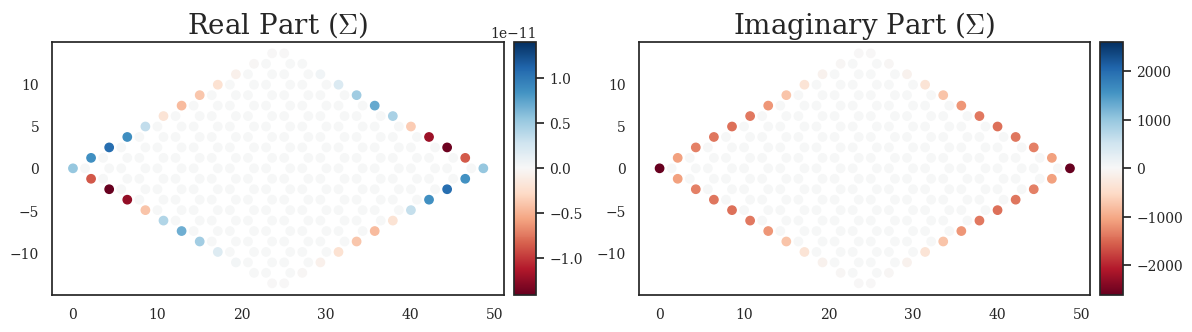

In [45]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
rse_diag = np.diagonal(RSE_E0).copy()
H = output["H_re"]
geomNN = H.geometry
x, y = H.geometry.xyz[:, :2].T

# Define the data parts and titles for a clean loop
E0_idx, = np.nonzero(ENERGIES == 0)
data_parts = [rse_diag.real, rse_diag.imag]
titles = [r"Real Part ($\Sigma$)", r"Imaginary Part ($\Sigma$)"]

imag_min = rse_diag.imag.min()
imag_max = rse_diag.imag.max()
print(imag_max, imag_min)

real_min = rse_diag.real.min()
real_max = rse_diag.real.max()
print(real_min, real_max)

            # real vals                     # imag values
vmins = [np.min([real_min, -real_max]), np.min([imag_min, -imag_max])]
vmaxs = [np.max([-real_min, real_max]), np.max([-imag_min, imag_max])]
# vmins = [-2e3,]*2
# vmaxs = [2e3,]*2
# vmins =[None,]*2
# vmaxs = vmins




fig, ax = plt.subplots(1,2, figsize=(12,12))
for i in range(2):
    # Create the scatter plot
    sc = ax[i].scatter(x, y, c=data_parts[i], cmap="RdBu", 
                        vmin=vmins[i], vmax=vmaxs[i])
    # for j in range(len(elist)): ax[i].text(geomNN.xyz[j, 0], geomNN.xyz[j, 1], s=elist[j], c="k")
    ax[i].set_title(titles[i], size=20)
    ax[i].axis("scaled")
    
    # --- The Colorbar Logic ---
    # Create a divider for the current axes
    divider = make_axes_locatable(ax[i])
    # Append an axes to the right, 5% width of the main plot
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc, cax=cax)

plt.tight_layout()
# plt.show()

 

In [46]:
# fig, ax = plt.subplots()
# HamSE = H.sub(output["electrode_idx"])
# for i in np.arange(0, geomNN.na):
#     if i < HamSE.na:
#         ax.text(geomNN.xyz[i, 0], geomNN.xyz[i, 1], s=i, c="k")
#         ax.scatter(geomNN.xyz[i, 0], geomNN.xyz[i, 1], c="b", s=10, label="Elec")
#     else:
#         ax.scatter(geomNN.xyz[i, 0], geomNN.xyz[i, 1], c="gray", s=10, label="Dev")
# for idx in np.arange(0, Ham0.na):
#     ax.scatter(Ham0.geometry.xyz[idx,0], Ham0.geometry.xyz[idx, 1], c="red", s=100, edgecolors="k", linewidth=1)
# ax.axis('scaled');

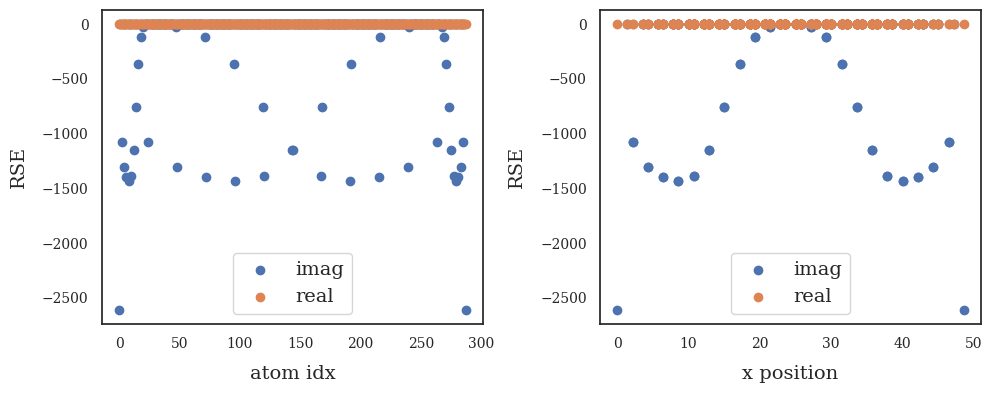

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(output["atoms_idx"], np.imag(RSE_E0).diagonal(), label="imag")
axes[0].scatter(output["atoms_idx"], np.real(RSE_E0).diagonal(), label="real")
axes[0].set(xlabel="atom idx", ylabel="RSE")
axes[0].legend(loc="lower center")
axes[1].scatter(geomNN.xyz[:, 0], np.imag(RSE_E0).diagonal(), label="imag")
axes[1].scatter(geomNN.xyz[:, 0], np.real(RSE_E0).diagonal(), label="real")
axes[1].set(xlabel="x position", ylabel="RSE")
axes[1].legend()
fig.tight_layout()


# Looping over tiling size

In [ ]:
a = np.array([1., 5.])
b = np.array([1, 2, 3, 4, 5])*(-1)
etas = np.multiply.outer(10.0**b, a).ravel()

'test'

In [ ]:
Ns = np.array([4*i+1 for i in range(2, 7)]); print(f"Ns : {Ns}, shape={Ns.shape}")
# nks = np.int16(np.ceil([(3+i)*900/Ns[i] for i in range(0,len(Ns))])); print(f"nks : {nks}, shape={nks.shape}")
nk1 = int(np.ceil(3*900/12))
eta = 1e-3j
energies = np.array([0])
OUTPUTS = {}

diffs = np.empty(shape=(len(Ns),), dtype=complex)
for i, N in enumerate(tqdm(Ns, desc="Looping tiling")):
    n0 = 0 # corner atom
    n_halfway_side = N//2+1
    E0_idx = energies[np.nonzero(energies == 0)]
    Ham0 = systemInit(1.43, -2.7)
    H_final, rse, alist, elist = setup_ham_rse(Ham0, tile=N, nk1=nk1, eta=eta)
    out = calculate_spectral_GF(energies, eta=eta, Ham_sub=H_final, rse=rse, alist=alist, elist=elist)
    out.pop("GF", None) # remove for use in webapp
    out.pop("H_re", None) # remove for use in webapp
    out["xyz"] = H_final.geometry.xyz
    
    
    OUTPUTS[f"{N}"] = out
    rse_re = out["RSE_re"]
    rse_diag = np.diagonal(rse_re, axis1=1, axis2=2).copy()
    rse_diff, = rse_diag[E0_idx, n0] - rse_diag[E0_idx, n_halfway_side]
    diffs[i] = rse_diff
OUTPUTS[f"diag_diff"] = diffs
import joblib
joblib.dump(OUTPUTS, out_dir / 'RSE_data_tiling_conv.pkl')
print(f"{OUTPUTS.keys()}")
print(OUTPUTS[list(OUTPUTS.keys())[0]].keys())


Ns : [ 9 13 17 21 25], shape=(5,)


Looping tiling:   0%|          | 0/5 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

Looping energies:   0%|          | 0/1 [00:00<?, ?it/s]

dict_keys(['9', '13', '17', '21', '25', 'diag_diff'])
dict_keys(['E', 'eta', 'H_re', 'electrode_idx', 'atoms_idx', 'GF', 'RSE_re', 'xyz'])


# Plots

### Plot Coupling to electrode sites for each energy

In [22]:
# @interact(dict=fixed(OUTPUTS), N=N_menu, part=part_menu, site=site_slider, nn=neighbour_slider) # make function interactive
def plot_size_conv(dict, N, part, site, nn, nn_pair=False):
    part = part.lower()
    current = dict[str(N)]
    
    # H_re = current["H_re"]
    # geom_re = H_re.geometry
    # x, y = geom_re.xyz[:, :2].T
    xyz = current["xyz"]
    x,y,z = xyz.T
    E = current["E"]
    # E0_idx = np.searchsorted(E, 0) # find the index where E==0 (or the first instance)
    RSE_re = current["RSE_re"]
    
    RSE_E0 = RSE_re[0, ...]
    
    if (part == "real"): #or (("r" in part) and ("i" not in part)):
        RSE_E0_part = np.real(RSE_E0)
    elif (part == "imag"): #or (("i" in part) and ("r" not in part)):
        RSE_E0_part = np.imag(RSE_E0)
        
    site_coupling = RSE_E0_part[site, :]
    
        
    vmax = np.max(np.abs(RSE_E0_part))
    vmin = -vmax
    
    # calculate distance  
    all_coords = xyz
    site_coord = xyz[[site],:]
    electrode_coords = xyz[:N, :]
    site_mask = np.delete(np.arange(0, xyz.shape[0]), site)
    diff = all_coords[:, None, :] - site_coord[None, :, :] # (M, 1, N) - (1, K, N) = (M, K, L)
    diff_site = site_coord[:, None, :] - electrode_coords[None, :, :] # (1, 1, N) - (1, M, N) = (1, M, N)
    dists = np.linalg.norm(diff, axis=2).squeeze()
    dists_site = np.linalg.norm(diff_site, axis=2).squeeze()
    
    ylim = (np.min(RSE_E0_part)*(1-2e-2), 
            np.max(RSE_E0_part)*(1+2e-1)
    )
    # calcualte xlim as the maximum distance to last atom on the side (from idx 0 to N-1)
    xlim = (0, np.linalg.norm(xyz[0, :] - xyz[N, :])*(1+1e-1)
    )
    # start figure
    fig, axes = plt.subplots(1,2, figsize=(10,4), dpi=150)
    # Left figure: scatter plot of distance and coupling 
    axes[0].scatter(dists[site_mask][N:], site_coupling[site_mask][N:], marker='.', color="r", s=15) # plot points not in first electrode side
    axes[0].scatter(dists[site_mask][:N], site_coupling[site_mask][:N], marker='+', color="b", s=30) # plot points IN the first electrode side
    axes[0].axhline(0, color="k",linestyle="--", linewidth=.8)
    
    # left axis params
    axes[0].set(xlabel=r"$r$ [$\mathrm{\AA}$]", 
                xlim=xlim,
                ylabel=rf"$\Sigma_{{{site}, j}}$", 
                ylim=ylim,
                title="Coupling Vs. distance"
    )
    
    # plot position colored by coupling
    sc = axes[1].scatter(x, y, c=site_coupling, vmin=vmin, vmax=vmax, cmap="RdBu", s=100/N)
    
    # right axis params
    axes[1].set(xlabel="$x$", 
                xticklabels="",
                ylabel="$y$",
                yticklabels="",
                title=rf"Coupling in 2D, $\Sigma_{{{site}, j}}$",
    )
    
    # Plot site on right plot, and NN on both
    # nearest_neighbours = nn
    farthest_dist = 0
    for s in np.arange(site-nn, site+nn+1, 1):
        if (0 <= s) and (s < N): # s has to be in valid range 
            if s != site: # if it is not the site, plot on both
                farthest_dist=np.max([farthest_dist, dists[s]])
                axes[1].text(x=x[s], y=y[s]-1, s=s, horizontalalignment="right", verticalalignment="top")   
            elif s == site: # if it is site, plot with arrow on right
                axes[1].annotate(site, xy=(x[site], y[site]), xycoords="data", xytext=(x[site]+2*N/9, y[site]+3*N/9), arrowprops={"color":"k", "width":0.10, "headwidth":3.0, "headlength": 4.0}, )
    if nn:
        farthest_nn_mask = np.nonzero(np.isclose(dists_site, farthest_dist, atol=1e-2))[0]
        if not nn_pair:
            farthest_nn_mask = farthest_nn_mask[[0]]
        
        # print(f"mask = {farthest_nn_mask}")
        # farthest_nn_mask = farthest_nn_mask[farthest_nn_mask < N]
        # print(f"mask = {farthest_nn_mask}")
        # farthest_nn_mask = np.unique(farthest_nn_mask)
        # print(f"mask = {farthest_nn_mask}")
        
        axes[0].axvline(farthest_dist, color='k', linestyle="--", lw=1, alpha=0.5)
        
        coupling_for_farthest_nn = site_coupling[farthest_nn_mask]
        for coup in coupling_for_farthest_nn:
            axes[0].annotate(text=f" {coup:.1f}", xy=(farthest_dist, coup), xytext=(farthest_dist, coup))
        
        
        
                
    axes[1].axis("off")
    axes[0].grid(True, which="both", linestyle="-", lw=0.2)
    
    # Add colorbar (using divider to match the rescaled box)
    divider = make_axes_locatable(axes[1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc, cax)
    
    
    #
    # fig.canvas.draw()
    fig.tight_layout()
# plot_size_conv(OUTPUTS, 9, "real", 0)
        

In [23]:
# N_options = np.array(list(OUTPUTS.keys())[:-1]).astype(int)
N_options = sorted([int(k) for k in OUTPUTS.keys() if k.isdigit()])
N_menu = Dropdown(value=N_options[0], options=N_options, description="Tiling, N =")
part_menu = Dropdown(value="imag", options=["real", "imag"], description="Part:")
site_slider = IntSlider(min=0, max=int(N_options[0])-1, step=1, description="Site:")
neighbour_slider = IntSlider(min=0, max=np.max(np.abs([site_slider.max - site_slider.value,  site_slider.value])), step=1, description="Neighbours")
show_nn_pair_box = widgets.Checkbox(value=False, description="Show pairs of NN")

def update_site_range(*args):
    new_n = int(N_menu.value) # if a new N is chosen, force update the IntSlider
    site_slider.max = new_n - 1 # set the max values of site_slider to N-1
    # neighbour_slider.max = np.abs(site_slider.max - site_slider.value)
    if site_slider.value > site_slider.max: # if current site_slider value exceedes max, set to max
        site_slider.value = site_slider.max
    # if neighbour_slider.value > neighbour_slider.max:
    #     neighbour_slider.value = neighbour_slider.max
def update_nn_range(*args):
    new_site = int(site_slider.value)
    neighbour_slider.max = np.max(np.abs([site_slider.max - new_site, new_site]))
    if site_slider.value > site_slider.max:
        site_slider.value = site_slider.max
N_menu.observe(update_site_range, 'value') # 'observe' how N_menu's value changes
site_slider.observe(update_nn_range, 'value')


ui = widgets.VBox([
    widgets.HBox([N_menu, site_slider]),
    widgets.HBox([part_menu, neighbour_slider, show_nn_pair_box]),
    # widgets.HBox([]),
])

out = widgets.interactive_output(plot_size_conv, {
    'dict': widgets.fixed(OUTPUTS),
    'N': N_menu,
    'part': part_menu,
    'site': site_slider,
    'nn': neighbour_slider,
    'nn_pair': show_nn_pair_box
})
display(ui, out)

Output()

# Tiling - $N$ vs. on-site/diagonal of self-energy, $|\Sigma_0 - \Sigma_{N/2}|$

In [35]:
H_final.geometry.close(3)
gr = sisl.geom.graphene_nanoribbon(6, vacuum=2, kind="armchair")
gr.set_nsc([3,3,1])

# gg = gr.tile(3,0).tile(3,1)
gg = gr.tile(1,0)
gg.plot(axes="xy")

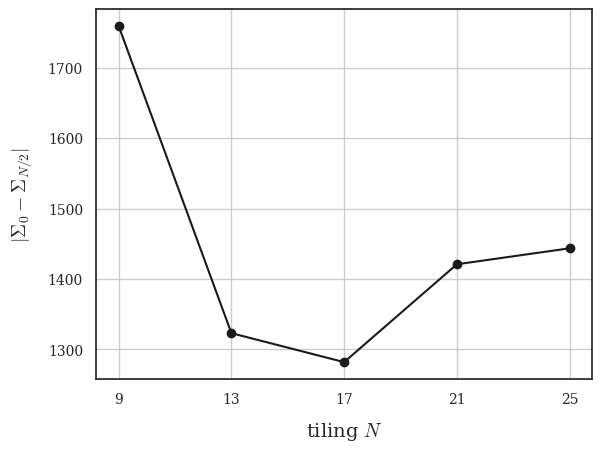

In [25]:
fig, ax = plt.subplots()
imag_diffs = np.imag(OUTPUTS["diag_diff"])
abs_imag_diffs = np.abs(imag_diffs)
ax.plot(Ns, abs_imag_diffs, 'ko-')
ax.set(xlabel="tiling $N$", ylabel=r"$|\Sigma_0 - \Sigma_{N/2}|$", xticks=Ns)
ax.grid()

In [ ]:
# Ns = np.array([4*i+1 for i in range(2, 11)]); print(f"Ns : {Ns}, shape={Ns.shape}")

# N_menu = Dropdown(value=Ns[0], options=Ns)
# part_options = ["real", "imag"]
# part_menu = Dropdown(value=part_options[1], options=part_options)
@interact(output=fixed(OUTPUTS), N=N_menu, part=part_menu, site=site_slider)
def plot_rse(output, N, part="imag", site=0):
    
    current_out = output[str(N)]
    rse = current_out["RSE_re"]
    energies = current_out["E"]
    E0_idx = np.searchsorted(energies, 0)
    rse_diag = rse[E0_idx].squeeze()[site, :]
    print("Num electrode atoms : {}".format(len(output[f"{N}"]["electrode_idx"])))
    
    if part.lower() == "real":
        rse_diag = np.real(rse_diag)
    elif part.lower() == "imag":
        rse_diag = np.imag(rse_diag)
    else:
        raise ValueError(f"part must be imag or real but was : '{part}'")
    
    # H = current_out["H_re"]
    xyz = current_out["xyz"]
    x,y = xyz[:, :2].T
    
    
    
    vmax = np.imag(rse[E0_idx]).max()
    vmin = np.imag(rse[E0_idx]).min()
    vmin = np.min([vmin, -vmax])
    vmax = np.max([-vmin, vmax])
    # vmax = 2.5e3
    # vmin = -vmax
    
    fig, ax = plt.subplots(figsize=(12,12))
    sc = ax.scatter(x, y, c=rse_diag, vmin=vmin, vmax=vmax, cmap="RdBu")
    ax.scatter(x[site], y[site], marker="+", s=100, color="k")
    ax.set(xlabel="x", ylabel="y",
           xticklabels="", yticklabels="",
           title=r"Diagonal elements of $\boldsymbol{\Sigma}^{(\mathrm{\mathbb{R}})}$"
           )
    divider = make_axes_locatable(ax)
    
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc, cax)
    ax.axis('scaled')
    
    

interactive(children=(Dropdown(description='Tiling, N =', options=(9, 13, 17, 21, 25), value=9), Dropdown(desc…

In [18]:
ns = np.array([int(key) for key in list(OUTPUTS.keys())[:-1]]); print(ns)
diff = OUTPUTS["diag_diff"]; print(diff)

[ 9 13 17 21 25]
[-4.47340269e-12-1758.84244493j -8.67747061e-12-1323.10502925j
 -1.07261479e-11-1282.01475595j  3.82588015e-12-1420.85176625j
 -2.13999207e-12-1443.52746418j]


[ 9 13 17 21 25]


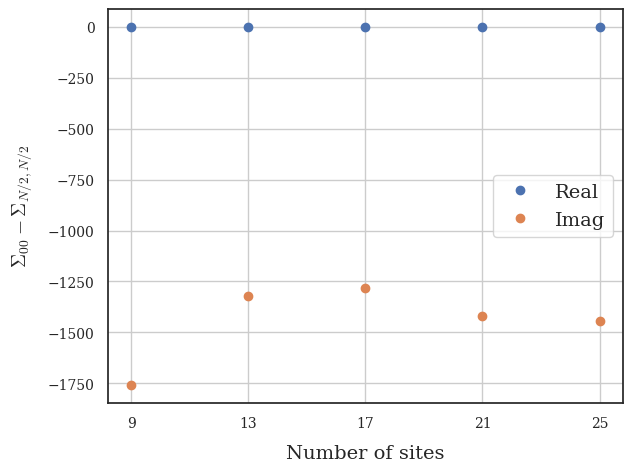

In [19]:
fig, axes = plt.subplots(1,1, sharey=1)
print(ns)
vals = [np.real(diff), np.imag(diff)]
parts = ["Real", "Imag"]
for val, part in zip(vals, parts):
    axes.plot(ns, val, 'o', label=part)
axes.set(xlabel="Number of sites", ylabel=r"$\Sigma_{00} - \Sigma_{N/2, N/2}$", xticks=ns)
axes.grid()
axes.legend(loc="center right")
fig.tight_layout()


In [20]:
n = 4
test = np.arange(n**2).reshape(n,n)
idx = np.random.choice(np.arange(0, n), replace=False, size=n)
print(idx)
print(test[np.ix_(idx, idx)])
print(test[idx,:][:, idx])
print(np.all(test[np.ix_(idx, idx)] == test[idx, :][:, idx]))

[3 1 0 2]
[[15 13 12 14]
 [ 7  5  4  6]
 [ 3  1  0  2]
 [11  9  8 10]]
[[15 13 12 14]
 [ 7  5  4  6]
 [ 3  1  0  2]
 [11  9  8 10]]
True
